# Chapter 6: 장중 거래와 시장 미시구조

공식 ES TAQ·volume bar·Coinsetter execution report를 사용해 trade sign, 체결가격, 주문장 상태를 재현한다. 장중 전략에서는 신호의 예측력만큼 거래 시계, 호가의 어느 편에서 체결했는지, 신호가 가용한 시점이 중요하다. 이 노트북은 한 거래일의 코드 의미와 실행 가정을 검증하는 실험이지, 전략의 장기 수익성을 입증하는 백테스트가 아니다.

In [1]:
from io import BytesIO
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
sys.path.insert(0, str(Path.cwd()))
import run_chapter6_analysis as ch6
data=ch6.load_data()
results=ch6.run_experiments(data)
checks=ch6.verify_results(data, results)
metrics=ch6.build_metrics(data, results, checks)
print(f"TAQ={len(data.tick_dn):,}, events={len(data.executions):,}, checks={sum(checks.values())}/{len(checks)}")

TAQ=77,390, events=246,060, checks=21/21


## 1. 문제 정의와 학습 질문

첫째, 같은 신호가 rounded midpoint와 bid-ask에서 왜 서로 반대 손익을 만드는가? 둘째, tick rule은 직전과 같은 가격의 거래를 어떻게 분류하고 그 선택이 60초 order flow에 어떤 기억을 남기는가? 셋째, 1초 wall clock과 500계약 volume clock은 활동이 집중된 구간을 어떻게 다르게 표현하는가? 넷째, 주문 추가·취소·체결을 받아 best bid/ask를 재구성할 때 어떤 데이터 오류를 감지해야 하는가?

In [2]:
def show_figure(fig):
    payload=BytesIO(); fig.savefig(payload,format='png',dpi=120,bbox_inches='tight'); plt.close(fig); display(Image(data=payload.getvalue()))
pd.DataFrame(ch6.coverage_matrix())

,topic,status,evidence
0,tick-rule trade classification,exact source replay,"77,390-row ES TAQ MAT"
1,bid-ask order-flow strategy,exact source-output comparison,four published outputs
2,midpoint execution,current-code replay + output-only comment,published trade counts contradict branch invar...
3,500-contract volume bars/BVC,source-semantic replay,"3,639-row MAT; source entry/exit thresholds 0...."
4,Coinsetter order-book reconstruction,independent Python port,"246,060 execution events"
5,Algoseek aggressor tags,code/output-only,aggressor input file absent
6,multi-day strategy performance,unavailable,single ES trading day only


## 2. 재현 상태와 coverage

`strict exact`는 원본이 게시한 숫자와 Python 계산을 허용오차 내에서 비교한다. `source-semantic`은 동일한 알고리즘을 실행했지만 원본 숫자가 없어 정확 재현을 주장하지 않는다. `independent port`는 MATLAB 상태 전이를 Python으로 옮기고 합성 사례로 동작을 검증한다. `output-only`는 입력이 없거나 원본 주석이 서로 모순되어 복사한 숫자를 실험 결과로 가장하지 않는다. coverage 표는 이 구분을 예제별로 드러낸다.

In [3]:
pd.Series(metrics['reproduction_classification']).apply(lambda x:', '.join(x))

exact_source_replay                                              tickRule.m bid-ask
source_semantic_or_independent            volumeBar.m, buildOrderBook.m Python port
output_only                       tick-rule midpoint execution comment, Algoseek...
dtype: str

## 3. provenance와 environment versions

공식 URL·archive SHA-256·7개 member checksum·uv.lock SHA·패키지 버전을 고정한다. offline 실행은 네트워크 없이 이를 전수 검사한다.

In [4]:
pd.Series({**metrics['provenance'],'uv_lock_sha256':metrics['environment']['uv_lock_sha256']})

source_page                                     https://epchan.com/book3
archive_url            https://epchan.com/img/book3/Chap6%20Intraday%...
archive_sha256         e8bceb329afcc9fe2c61bcd06f553a5fa5dbe569716b22...
archive_size_bytes                                               7141666
member_count                                                           7
matlab_source_count                                                    4
research_data_count                                                    3
manifest_sha256        a2adca65dafbefb46cef0acf2e24611b62ac2556f37895...
uv_lock_sha256         34057457773a614f058648f3ba9ba2f02f02354f64214e...
dtype: object

## 4. 데이터 구조와 결측 진단

TAQ 77,390행은 2012-10-01의 거래가, 거래량, bid, ask와 MATLAB datenum을 담는다. 계산 전에 timestamp가 엄격히 증가하는지, bid가 ask를 넘지 않는지, 거래가와 호가에 결측이 없는지를 검사한다. 3,639행 volume-bar MAT은 행당 500계약으로 정의된다. Coinsetter CSV는 246,060개 event를 순서대로 담지만, 교차 호가와 존재하지 않는 level 감소가 있어 정제된 NBBO로 보면 안 된다. 이 세 데이터는 trade-event, volume, wall clock이라는 서로 다른 시계를 제공한다.

In [5]:
pd.DataFrame(metrics['data']).T

,rows,date_start,date_end,missing_trade_price,median_spread_points,bad_last_price,contracts_per_bar,sequence_start,sequence_end
es_tick,77390,2012-10-01 00:00:00.625001669+00:00,2012-10-01 23:59:55.049996614+00:00,0,0.25,NaN,NaN,NaN,NaN
es_volume_bar,3639.0,NaN,NaN,NaN,NaN,0.0,500.0,NaN,NaN
coinsetter,246060.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,246059.0


## 5. 수식 → 코드: tick rule

$$OF_t=\sum_{t-60s<i\leq t} q_i s_i, \qquad s_i\in\{-1,+1\}.$$

`tick_rule_order_flow()`는 가격 상승을 +1, 하락을 -1로 분류하고 동가이면 직전 sign을 이어받는다. `rolling_flow()`는 현재 event를 포함한 60초 signed volume을 더한다. `execute_flow_strategy()`는 order flow가 +66 이상이면 long, -66 이하이면 short에 진입하고 0을 통과하면 청산한다. 신호와 현재 quote를 같은 event에서 사용하므로 이는 latency가 없는 원본 의미의 재현이며, 미래 체결 가능성을 검증한 예측 모형은 아니다.

In [6]:
pd.Series({'signed_volume_sum':results['tick_rule']['order_flow'].sum(),'rolling_flow_5pct':pd.Series(results['tick_rule']['rolling_flow']).quantile(.05),'rolling_flow_95pct':pd.Series(results['tick_rule']['rolling_flow']).quantile(.95)})

signed_volume_sum     434949.00
rolling_flow_5pct      -2657.00
rolling_flow_95pct      7344.05
dtype: float64

## 6. ES TAQ 시각 진단

호가 spread와 trade path를 함께 봐야 체결 가정의 크기를 이해할 수 있다. midpoint는 실제 bid/ask 사이의 회계적 기준일 뿐 보장된 체결가격이 아니다.

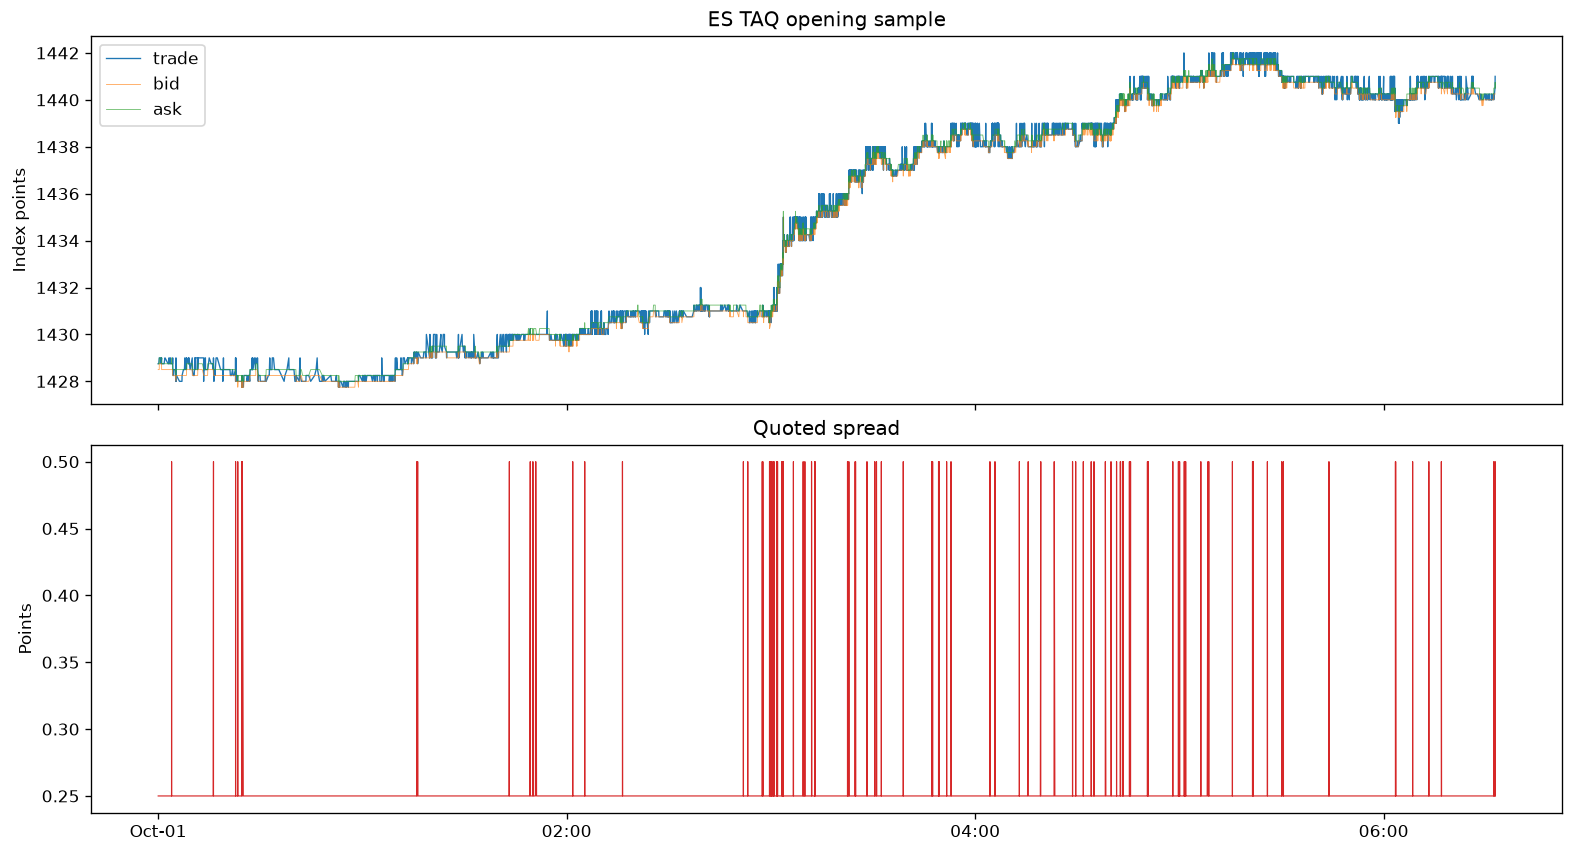

In [7]:
show_figure(ch6.plot_tick_diagnostics(data))

## 7. 원본 MATLAB exact 비교

bid-ask 경로의 gross P&L, trade당 P&L, 거래 수, fee를 `tickRule.m`의 소수 6자리 주석과 비교한다. 소수 지표의 허용오차 5e-7은 원본 표시 자릿수의 반올림 반폭이고, 정수 trade count는 완전 일치를 요구한다. 네 지표가 모두 통과해야 exact replay로 인정한다. 총손익이 -6,687.50달러이고 수수료를 더하면 -6,800.55달러이므로, 스프레드 체결만으로 이 신호의 날짜 내 성과는 사라진다.

In [8]:
pd.DataFrame(metrics['book_comparisons'])

,strategy,metric,python,source,absolute_error,tolerance,matches_source
0,tickRule.m bid-ask execution,gross_pl_usd,-6687.500000,-6687.500000,0.000000e+00,5.000000e-07,True
1,tickRule.m bid-ask execution,pl_per_trade_usd,-5.619748,-5.619748,1.008403e-07,5.000000e-07,True
2,tickRule.m bid-ask execution,num_trades,1190.000000,1190.000000,0.000000e+00,0.000000e+00,True
3,tickRule.m bid-ask execution,total_fee_usd,113.050000,113.050000,0.000000e+00,5.000000e-07,True


## 8. midpoint 주석의 모순

`useMidPrice`는 체결가 계산 branch일 뿐 entry·exit decision에 사용되지 않는다. 따라서 같은 입력이면 midpoint와 bid-ask의 거래 수는 같아야 한다. current-code replay는 둘 다 1,190건이지만 원본 주석은 1,168건과 1,190건을 적어 놓았다. 어느 주석이 stale인지 추측해 가장하지 않고, midpoint 주석 결과는 `compared:false` 및 기계 판독 사유와 함께 output-only로 남긴다. 이 구분은 “코드를 실행했다”와 “출판된 숫자를 재현했다”가 다른 주장임을 보여준다.

In [9]:
pd.DataFrame(metrics['reference_only_comparisons'])[['topic','compared','reason']]

,topic,compared,reason
0,tick-rule midpoint execution comment,False,The execution-price branch cannot change signa...
1,Algoseek aggressor-tag strategy,False,The downloadable TAQ MAT has prices and volume...
2,multi-day profitability,False,The bundled ES examples contain one trading da...


## 9. 실행가 민감도

현재 rounded midpoint는 플러스, bid-ask는 큰 마이너스다. signal alpha보다 spread와 체결 위치가 더 크다는 사실을 그림으로 확인한다.

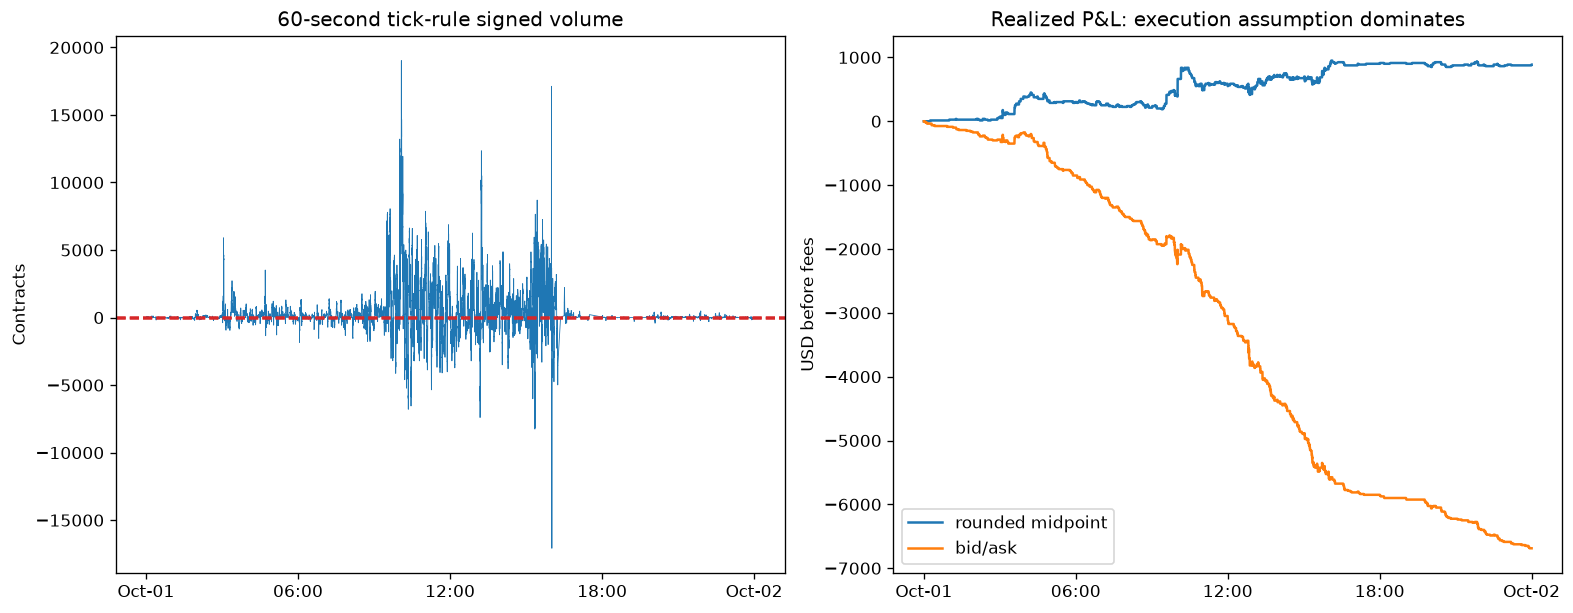

In [10]:
show_figure(ch6.plot_tick_strategy(data,results))

## 10. volume bars와 BVC

volume clock은 500계약이 쌓일 때마다 한 칸 움직인다. 거래가 활발하면 wall-clock 1초 안에 여러 bar가 만들어지고 한산하면 한 bar가 긴 시간을 덮는다. `volume_bar_experiment()`은 최근 100개 bar 가격변화의 표본 표준편차로 현재 변화를 표준화하고 정규 CDF를 buy fraction으로 근사한다. 원본의 entry threshold 0.95에 따라 0.95 초과는 long, 0.05 미만은 short로 진입한다. exit threshold 0.5에 따라 long은 fraction이 0.5 이하일 때, short는 0.5 이상일 때 청산하며 그 전의 중립 구간에서는 포지션을 유지한다. 구현은 `buy_fraction - 0.5`로 중심화해 이 네 부등식을 공통 실행 엔진에 정확히 대응한다. 원본에 비교할 숫자가 없으므로 계산값은 교육용 source-semantic 실험이며, 단일 성과를 독립 재현으로 표현하지 않는다.

lookback_bars                                                                           100
bar_volume_contracts                                                                    500
contract                                  {'entry_threshold': 0.95, 'exit_threshold': 0....
source_has_no_published_numeric_output                                                 True
dtype: object

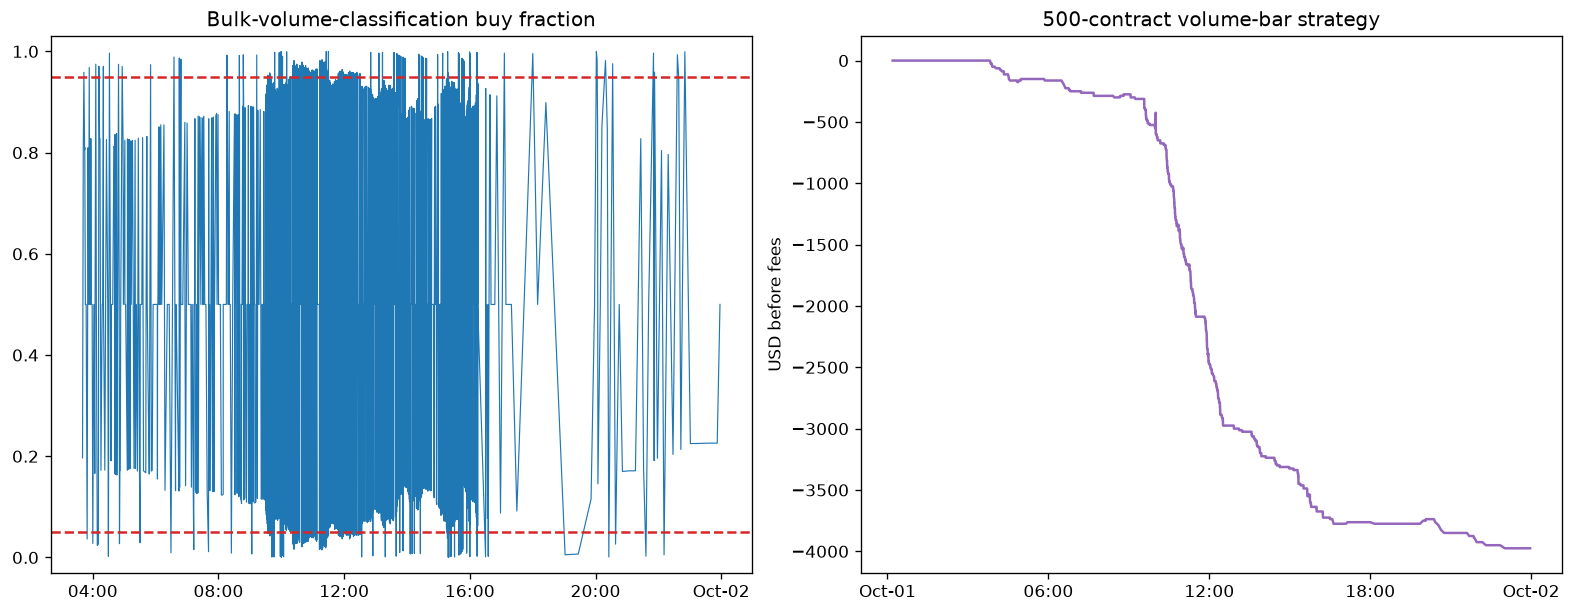

In [11]:
display(pd.Series({k:v for k,v in metrics['results']['volume_bar'].items() if k!='strategy'})); show_figure(ch6.plot_volume_bars(results))

## 11. 주문장 state machine

`WORKING_CONFIRMED`는 side의 가격 level에 수량을 더한다. `CANCEL_CONFIRMED`, `FILL_CONFIRMED`, `PARTIAL_FILL_CONFIRMED`는 해당 level의 수량을 줄이고 0이 되면 level을 제거한다. best bid는 남은 buy level의 최대값, best ask는 sell level의 최소값이다. `apply_book_event()`를 합성 주문에 적용해 수량 5인 level이 partial fill 2 후 3으로 남는지 별도 검증한다. 초 단위 bar는 해당 초 마지막 event 후의 top-of-book을 기록한다.

In [12]:
pd.Series(metrics['results']['order_book'])

events                                                                        246060
bars                                                                          233072
action_counts                      {'CANCEL_CONFIRMED': 111962, 'PARTIAL_FILL_CON...
side_counts                                          {'BUY': 115485, 'SELL': 130575}
valid_two_sided_bars                                                          232940
median_spread                                                                -250.83
crossed_event_states                                                          245420
invalid_missing_reductions                                                     13731
invalid_oversize_reductions                                                      369
sequence_is_strictly_increasing                                                 True
dtype: object

## 12. Coinsetter 데이터 진단

SequenceNumber의 엄격한 증가, 누락 level 감소, 보유 수량보다 큰 oversize 감소, bid가 ask보다 큰 crossed state를 모두 기록한다. 원본 MATLAB도 일부 잘못된 trade를 인정하고 bid-ask assertion을 주석 처리했다. 재구성 median spread가 음수라는 점은 사실적 시장 spread 추정치가 아니라 order state가 오염됐다는 강한 경고다. 교차 상태를 임의로 필터하면 그럴듯한 차트는 만들 수 있지만, 원본 데이터의 불완전성을 숨기게 된다. 따라서 이 구간은 매매 신호가 아니라 데이터 품질 실험으로 읽어야 한다.

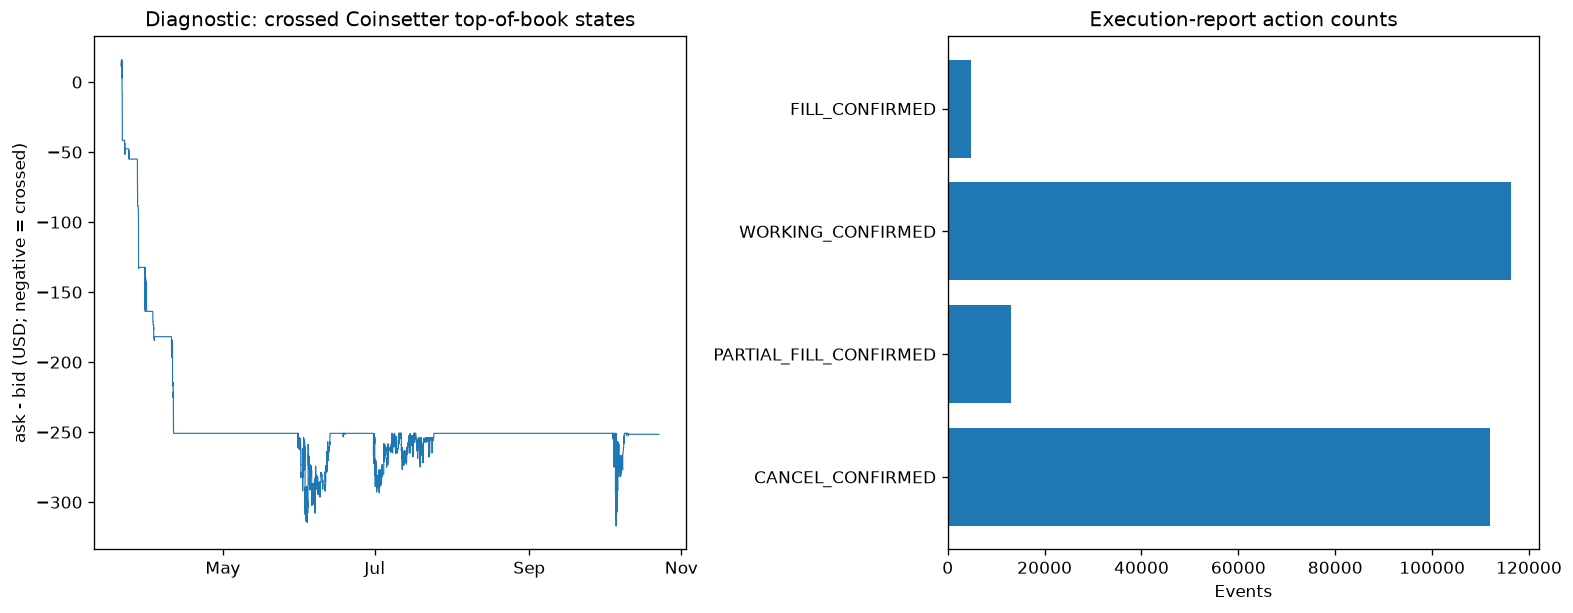

In [13]:
show_figure(ch6.plot_order_book(results))

## 13. 거래비용·슬리피지·latency

0.095/0.16/2.47달러 fee를 비교한다. spread는 bid-ask 체결에 포함되지만 market impact, queue position, network latency는 포함되지 않는다.

0.095   -6800.55
0.16    -6877.90
2.47    -9626.80
dtype: float64

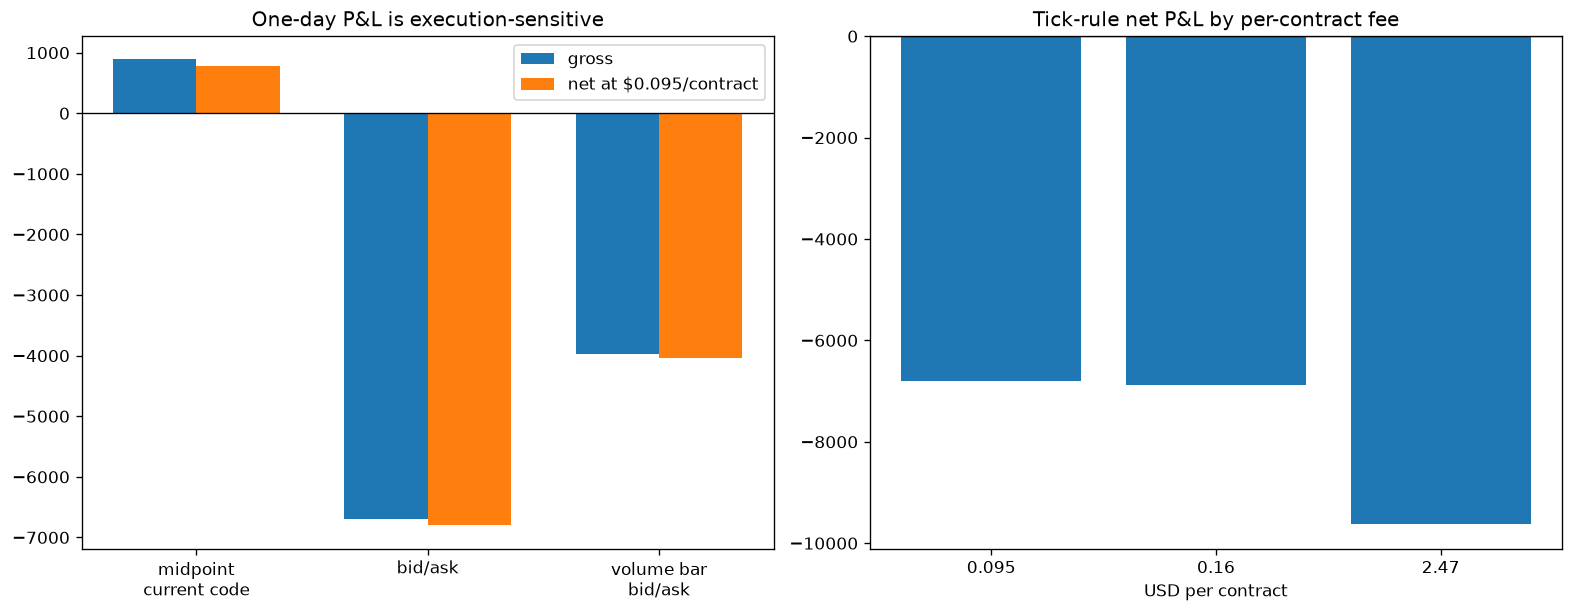

In [14]:
display(pd.Series(results['tick_rule']['fee_sensitivity'])); show_figure(ch6.plot_cost_comparison(results))

## 14. 표본 외 부재

ES 샘플은 단 하루이고 threshold 66도 같은 날의 예제에서 선택됐으므로 selection bias가 있다. 임계값, lookback, 청산 규칙을 같은 날에서 반복 탐색하면 data snooping이 커진다. 실전 평가는 여러 월의 뉴스일·저활동일·고변동일을 시간 순서로 나누고, 과거에서만 선택한 파라미터를 다음 기간에 고정하는 walk-forward가 필요하다. 여기에는 그런 out-of-sample 구간이 없으므로 Sharpe와 annual return을 주장하지 않는다.

## 15. 위험지표 범위

CAGR·Sharpe·drawdown·Calmar를 한 거래일에 연율화하면 표본 수가 거의 없는 숫자에 잘못된 정밀도를 부여한다. 따라서 이 노트북은 달러 총손익, trade count, trade당 손익과 fee만 보고한다. 또한 realized P&L path는 청산 event에서만 손익을 반영하므로 중간 미청산 포지션의 mark-to-market과 intraday drawdown이 빠져 있다. 이것이 위험지표 해석의 핵심 한계이며, 해당 path를 완전한 equity curve로 보지 않는다.

## 16. deterministic contract

난수를 쓰지 않지만 random seed = 20260718을 재현 메타데이터에 고정한다. 고정 셀 ID와 PNG metadata로 연속 빌드 해시도 동일하게 만든다.

In [15]:
pd.Series({'random_seed':20260718,'uses_randomness':False,'notebook_cell_ids':'deterministic'})

random_seed               20260718
uses_randomness              False
notebook_cell_ids    deterministic
dtype: object

## 17. 자동 verification

21개 검사는 단순히 같은 결과를 다시 비교하는 항목과 외부 증거를 분리한다. archive hash, 7개 member, 4개 MATLAB source, 77,390개 timestamp·quote, 246,060개 sequence, 원본 출력 4개 일치는 독립·경험 검사다. 수수료 단조성, 입력 부재 공개, output-only 사유, 단일 샘플 경고는 contract invariant다. synthetic partial fill은 상태 전이가 수량 5에서 3으로 줄어드는지 독립적으로 검사한다. 모든 항목이 참일 때만 산출물을 완성한다.

In [16]:
verification=pd.Series(checks,name='passed'); display(verification); assert verification.all(); print(f"verification passed: {verification.sum()}/{len(verification)}")

archive_manifest_matches                     True
all_seven_archive_members_pinned             True
four_matlab_sources_present                  True
tick_timestamps_are_strictly_increasing      True
tick_quotes_are_not_crossed                  True
tick_rule_bidask_matches_source              True
midpoint_and_bidask_share_trade_decisions    True
stale_midpoint_comment_is_not_compared       True
fees_do_not_improve_tick_strategy            True
volume_bar_contract_matches_source           True
volume_bar_probabilities_are_bounded         True
volume_bar_source_output_not_invented        True
order_book_sequence_is_strict                True
order_book_event_count_matches_csv           True
order_book_has_two_sided_bars                True
synthetic_partial_fill_reduces_size          True
all_reference_only_rows_have_reasons         True
aggressor_data_is_not_claimed_available      True
single_day_is_not_claimed_out_of_sample      True
bidask_execution_is_worse_than_midpoint      True


verification passed: 21/21


## 18. 결론

이 장의 가장 큰 결과는 midpoint의 +887.50달러가 bid-ask에서 -6,687.50달러로 바뀐다는 점이다. 같은 신호와 trade decision에서 체결가 가정만으로 결론이 뒤집혔다. volume clock은 활동 집중을 다른 방식으로 보여주지만 숫자 원본 비교가 없고, Coinsetter 주문장은 교차 상태 때문에 신호 입력으로 바로 쓸 수 없다. 따라서 장중 전략은 alpha를 논하기 전에 데이터 clock, trade sign, quote side, event ordering, fee, latency를 고정해야 한다. 다음 단계는 여러 날의 정제된 event data에서 현실적 지연·slippage를 넣은 walk-forward 평가이며, 이 노트북의 단일 실험은 그 결론을 대신하지 않는다.